# Exploratory Data Analysis (EDA) - Fraud Detection

# Fraud Detection Dataset Overview

## Objective
Build a real-time fraud detection system capable of:
- identifying fraudulent transactions
- minimizing false negatives
- providing explainable predictions

## Dataset
- Source: IEEE-CIS Fraud Detection (Kaggle)
- Provider: Vesta Corporation
- Target Column: isFraud
- Problem Type: Binary Classification

## Files Used
- train_transaction.csv
- train_identity.csv

## Key Challenge
Extreme class imbalance and highly anonymized features.

# Strategic Fraud Analysis: Key Business Questions

This document outlines the five fundamental questions that drive fraud intelligence, model architecture, and financial optimization.

---

### 1. What Percentage of Transactions Are Fraudulent?
* **Measurement:** Quantifies fraud prevalence, dataset imbalance, and operational risk exposure.
* **ML Strategy:** Directly influences sampling techniques, evaluation metrics (AUPRC vs. Accuracy), and threshold tuning.
* **Business Impact:** Used to monitor trends, seasonal spikes, and abnormal surges.

### 2. Which Features Most Strongly Predict Fraud?
* **Objective:** Identify behavioral signals (velocity), suspicious patterns (high amounts), and high-risk user behaviors (mismatched addresses/device inconsistencies).
* **ML Strategy:** Drives feature engineering and dimensionality reduction.
* **Business Impact:** Provides actionable intelligence and interpretable risk factors for fraud analyst workflows.

### 3. What Is the Financial Value of Fraud Caught vs. Missed?
* **Objective:** Shift focus from classification accuracy to business optimization.
* **The Math:** Balancing **Fraud Caught** (Money Saved) vs. **Fraud Missed** (Financial Loss) vs. **False Positives** (Customer Friction/Churn).
* **Business Impact:** A model with lower recall but significantly fewer false positives is often more profitable.

### 4. Which Transaction Types Are Riskiest?
* **Segments:** Analyze fraud rates across `ProductCD`, card brands, payment types, email domains, and timing.
* **ML Strategy:** Enables segment-specific modeling or localized feature weighting.
* **Business Impact:** Informs adaptive fraud rules and risk-based authentication (RBA) strategies.

### 5. Can We Explain WHY a Transaction Was Flagged?
* **Objective:** Move from "Black Box" to "Glass Box" modeling.
* **Technical Requirement:** Implement SHAP/LIME for feature attribution and local prediction explanations.
* **Business Impact:** Essential for regulatory transparency, analyst trust, and handling customer disputes.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost
import shap
import mlflow

print("Notebook environment ready")

Notebook environment ready


# Data Loading & Merging

In [3]:
# =========================================================
# SET PROJECT ROOT PATH
# =========================================================

import sys
from pathlib import Path

# Add project root to Python path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

print("Project root added:", project_root)

Project root added: H:\fraud-detection


In [4]:
from config import (
    RAW_DATA_PATH,
    TRAIN_TRANSACTION_FILE,
    TRAIN_IDENTITY_FILE
)

sns.set_style("whitegrid")

print("Data loaded successfully")

Data loaded successfully


In [5]:
# =========================================================
# LOAD DATASETS
# =========================================================

train_transaction = pd.read_csv(
    RAW_DATA_PATH / TRAIN_TRANSACTION_FILE
)

train_identity = pd.read_csv(
    RAW_DATA_PATH / TRAIN_IDENTITY_FILE
)

print("Transaction Shape:", train_transaction.shape)
print("Identity Shape:", train_identity.shape)

Transaction Shape: (590540, 394)
Identity Shape: (144233, 41)


In [6]:
# =========================================================
# MERGE DATASETS
# =========================================================

df = pd.merge(
    train_transaction,
    train_identity,
    how="left",
    on="TransactionID"
)

print("Merged Dataset Shape:", df.shape)

df.head()

Merged Dataset Shape: (590540, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [7]:
# MEMORY USAGE

memory_usage_mb = df.memory_usage(deep=True).sum() / 1024**2

print(f"Dataset Memory Usage: {memory_usage_mb:.2f} MB")

Dataset Memory Usage: 2567.09 MB


### Findings

- Successfully loaded transaction and identity datasets
- Identity dataset contains fewer rows than transaction dataset
- Left join preserves all transactions
- Merged dataset contains both transactional and device-level signals
- Significant missing values are expected in identity-related columns

# Basic Dataset Overview

In [8]:
# FIRST LOOK AT DATA
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [9]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 1.9+ GB


,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,...,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_32
count,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540.000000,581607.000000,588975.000000,586281.000000,524834.000000,524834.000000,...,139369.000000,45113.000000,139318.000000,139261.000000,5159.000000,5169.000000,4747.000000,5132.000000,5163.000000,77586.000000
mean,3.282270e+06,0.034990,7.372311e+06,135.027176,9898.734658,362.555488,153.194925,199.278897,290.733794,86.800630,...,189.451377,14.237337,353.128174,403.882666,368.269820,16.002708,12.800927,329.608924,149.070308,26.508597
std,1.704744e+05,0.183755,4.617224e+06,239.162522,4901.170153,157.793246,11.336444,41.244453,101.741072,2.690623,...,30.375360,1.561302,141.095343,152.160327,198.847038,6.897665,2.372447,97.461089,32.101995,3.737502
min,2.987000e+06,0.000000,8.640000e+04,0.251000,1000.000000,100.000000,100.000000,100.000000,100.000000,10.000000,...,100.000000,10.000000,100.000000,100.000000,100.000000,10.000000,11.000000,100.000000,100.000000,0.000000
25%,3.134635e+06,0.000000,3.027058e+06,43.321000,6019.000000,214.000000,150.000000,166.000000,204.000000,87.000000,...,166.000000,13.000000,266.000000,256.000000,252.000000,14.000000,11.000000,321.000000,119.000000,24.000000
50%,3.282270e+06,0.000000,7.306528e+06,68.769000,9678.000000,361.000000,150.000000,226.000000,299.000000,87.000000,...,166.000000,15.000000,341.000000,472.000000,252.000000,14.000000,11.000000,321.000000,149.000000,24.000000
75%,3.429904e+06,0.000000,1.124662e+07,125.000000,14184.000000,512.000000,150.000000,226.000000,330.000000,87.000000,...,225.000000,15.000000,427.000000,533.000000,486.500000,14.000000,15.000000,371.000000,169.000000,32.000000
max,3.577539e+06,1.000000,1.581113e+07,31937.391000,18396.000000,600.000000,231.000000,237.000000,540.000000,102.000000,...,229.000000,29.000000,671.000000,661.000000,854.000000,44.000000,26.000000,548.000000,216.000000,32.000000


In [10]:
# CATEGORICAL SUMMARY
df.describe(include='object')

,ProductCD,card4,card6,P_emaildomain,R_emaildomain,M1,M2,M3,M4,M5,...,id_30,id_31,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
count,590540,588963,588969,496084,137291,319440,319440,319440,309096,240058,...,77565,140282,73289,77805,140985,140985,140985,140985,140810,118666
unique,5,4,4,59,60,2,2,2,3,2,...,75,130,260,4,2,2,2,2,2,1786
top,W,visa,debit,gmail.com,gmail.com,T,T,T,M0,F,...,Windows 10,chrome 63.0,1920x1080,match_status:2,T,F,T,F,desktop,Windows
freq,439670,384767,439938,228355,57147,319415,285468,251731,196405,132491,...,21155,22000,16874,60011,77814,134066,110452,73922,85165,47722


In [11]:
# DATA TYPE COUNTS
df.dtypes.value_counts()

float64    399
object      31
int64        4
Name: count, dtype: int64

In [12]:
# COLUMN TYPE SEPARATION

numerical_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_cols = df.select_dtypes(
    include=['object']
).columns

print(f"Number of Numerical Columns: {len(numerical_cols)}")
print(f"Number of Categorical Columns: {len(categorical_cols)}")

Number of Numerical Columns: 403
Number of Categorical Columns: 31


In [13]:
# MISSING VALUE OVERVIEW

missing_percent = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percent.head(20)

id_24    99.196159
id_25    99.130965
id_07    99.127070
id_08    99.127070
id_21    99.126393
id_26    99.125715
id_27    99.124699
id_23    99.124699
id_22    99.124699
dist2    93.628374
D7       93.409930
id_18    92.360721
D13      89.509263
D14      89.469469
D12      89.041047
id_03    88.768923
id_04    88.768923
D6       87.606767
id_33    87.589494
id_10    87.312290
dtype: float64

### Key Findings

- Dataset contains a large number of numerical features
- Significant missing values exist across identity and V-features
- Several categorical columns require encoding
- Many features appear highly sparse
- Fraud dataset is heavily engineered and behavior-focused

# Target Variable Analysis

In [14]:
# TARGET VARIABLE DISTRIBUTION

fraud_counts = df['isFraud'].value_counts()

print(fraud_counts)

isFraud
0    569877
1     20663
Name: count, dtype: int64


In [15]:
# Fraud Percentage
fraud_rate = (
    df['isFraud'].value_counts(normalize=True) * 100
)
print(fraud_rate)

isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


# Fraud Class Visualization

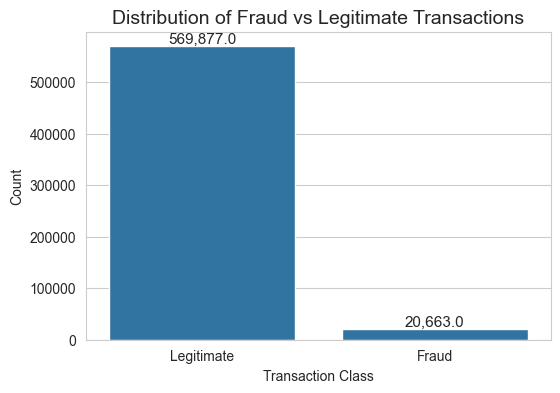

In [16]:
plt.figure(figsize=(6, 4))

ax = (
    sns.countplot(x='isFraud', data=df)
)

# Add count labels
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():,}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.title(
    'Distribution of Fraud vs Legitimate Transactions',
    fontsize=14
)

plt.xlabel('Transaction Class')
plt.ylabel('Count')

plt.xticks(
    [0, 1],
    ['Legitimate', 'Fraud']
)

plt.show()

In [17]:
# FRAUD RATE SUMMARY

fraud_percentage = (
    df['isFraud'].mean() * 100
)

print(f"Fraud Rate: {fraud_percentage:.2f}%")

Fraud Rate: 3.50%


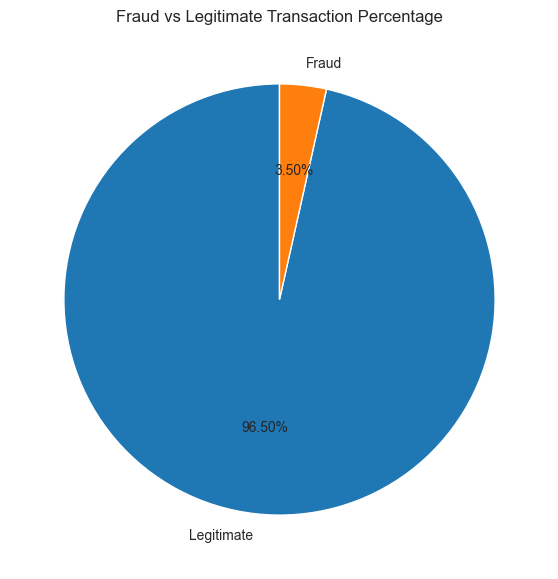

In [18]:
# FRAUD PERCENTAGE PIE CHART

class_percentages = (
    df['isFraud']
    .value_counts(normalize=True)
    * 100
)

plt.figure(figsize=(7, 7))

plt.pie(
    class_percentages,
    labels=['Legitimate', 'Fraud'],
    autopct='%1.2f%%',
    startangle=90
)

plt.title(
    'Fraud vs Legitimate Transaction Percentage'
)

plt.show()

### Findings

- Fraudulent transactions represent only a small percentage of the dataset
- The dataset is severely imbalanced
- Accuracy alone would be misleading for this problem
- Special imbalance handling techniques will be required
- Recall and PR-AUC will be critical evaluation metrics

# Missing Value Analysis

In [19]:
# MISSING VALUE PERCENTAGE

missing_percent = (
    df.isnull()
    .mean()
    * 100
).sort_values(ascending=False)

missing_percent.head(20)

id_24    99.196159
id_25    99.130965
id_07    99.127070
id_08    99.127070
id_21    99.126393
id_26    99.125715
id_27    99.124699
id_23    99.124699
id_22    99.124699
dist2    93.628374
D7       93.409930
id_18    92.360721
D13      89.509263
D14      89.469469
D12      89.041047
id_03    88.768923
id_04    88.768923
D6       87.606767
id_33    87.589494
id_10    87.312290
dtype: float64

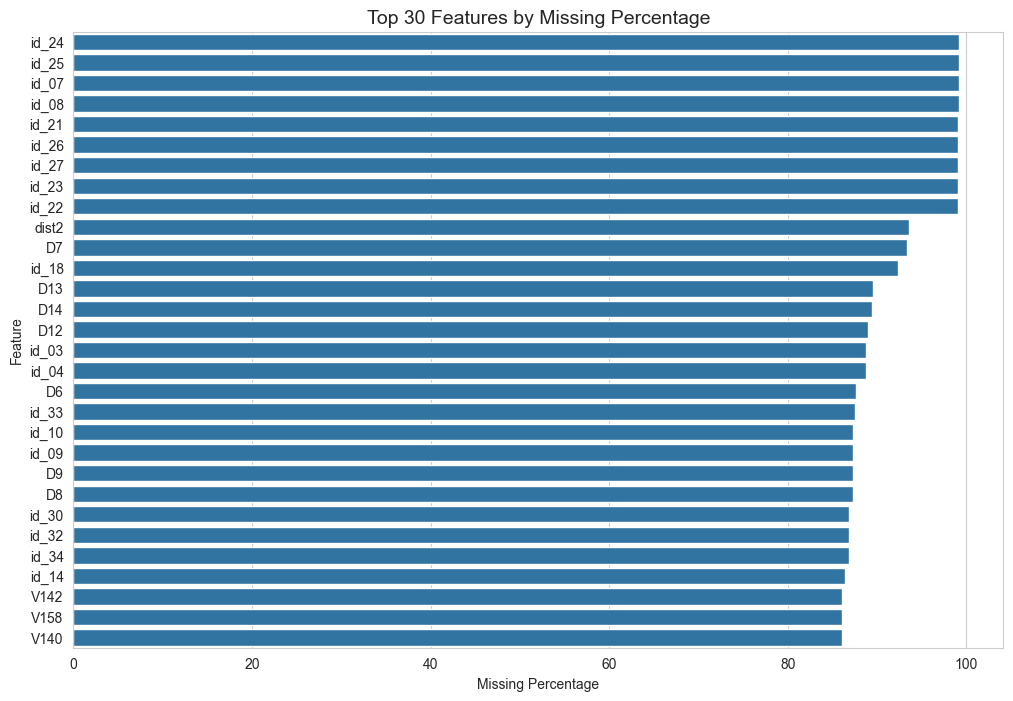

In [20]:
# TOP 30 MISSING COLUMNS

top_missing = missing_percent.head(30)

plt.figure(figsize=(12, 8))

sns.barplot(
    x=top_missing.values,
    y=top_missing.index
)

plt.title(
    'Top 30 Features by Missing Percentage',
    fontsize=14
)

plt.xlabel('Missing Percentage')
plt.ylabel('Feature')

plt.show()

In [21]:
# HIGH MISSING VALUE COUNTS

missing_50 = (missing_percent > 50).sum()
missing_75 = (missing_percent > 75).sum()
missing_90 = (missing_percent > 90).sum()

print(f"Columns with >50% missing: {missing_50}")
print(f"Columns with >75% missing: {missing_75}")
print(f"Columns with >90% missing: {missing_90}")

Columns with >50% missing: 214
Columns with >75% missing: 208
Columns with >90% missing: 12


In [22]:
# FEATURE GROUP MISSINGNESS

feature_groups = {
    'V Features': [col for col in df.columns if col.startswith('V')],
    'D Features': [col for col in df.columns if col.startswith('D')],
    'C Features': [col for col in df.columns if col.startswith('C')],
    'M Features': [col for col in df.columns if col.startswith('M')],
    'ID Features': [col for col in df.columns if col.startswith('id_')]
}

group_missing = {}

for group, cols in feature_groups.items():
    group_missing[group] = df[cols].isnull().mean().mean() * 100

group_missing_df = pd.DataFrame({
    'Feature Group': group_missing.keys(),
    'Average Missing %': group_missing.values()
})

group_missing_df

,Feature Group,Average Missing %
0,V Features,43.038469
1,D Features,60.490010
2,C Features,0.000000
3,M Features,49.923328
4,ID Features,84.823271


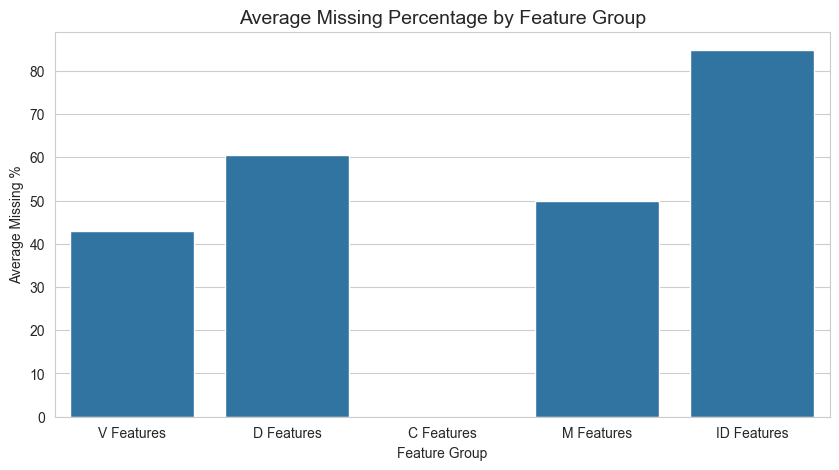

In [23]:
# GROUP-LEVEL MISSINGNESS VISUALIZATION

plt.figure(figsize=(10, 5))

sns.barplot(
    x='Feature Group',
    y='Average Missing %',
    data=group_missing_df
)

plt.title(
    'Average Missing Percentage by Feature Group',
    fontsize=14
)

plt.ylabel('Average Missing %')
plt.xlabel('Feature Group')

plt.show()

In [24]:
# COLUMNS WITH >90% MISSING

high_missing_cols = missing_percent[
    missing_percent > 90
].index.tolist()

print(f"Number of columns >90% missing: {len(high_missing_cols)}")

high_missing_cols[:20]

Number of columns >90% missing: 12


['id_24',
 'id_25',
 'id_07',
 'id_08',
 'id_21',
 'id_26',
 'id_27',
 'id_23',
 'id_22',
 'dist2',
 'D7',
 'id_18']

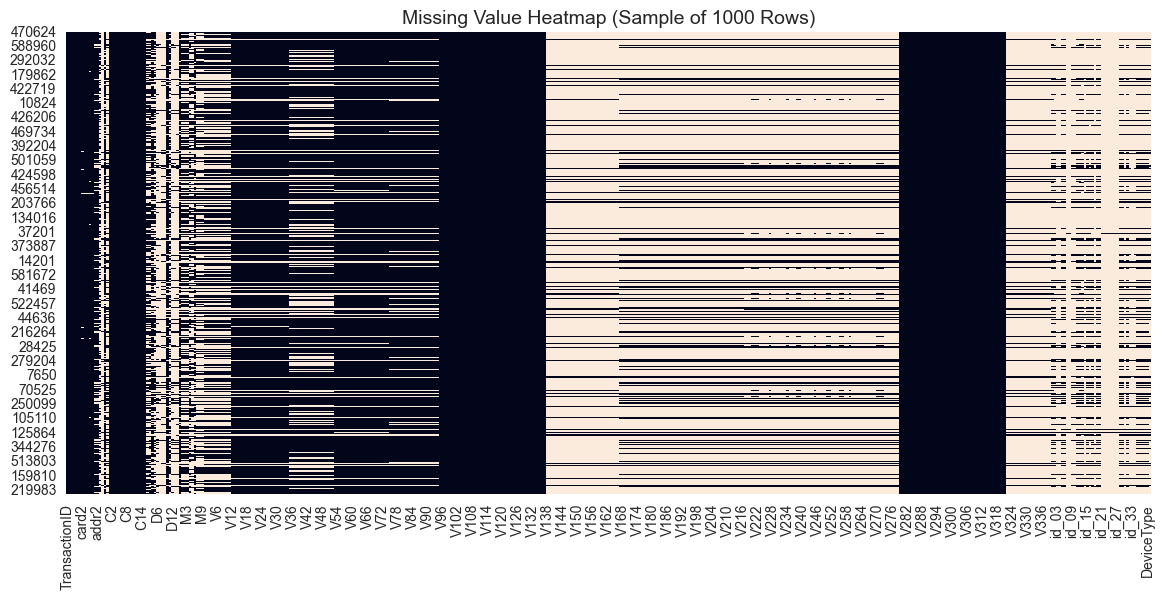

In [25]:
# MISSING VALUE HEATMAP (SAMPLE)

sample_df = df.sample(1000, random_state=42)

plt.figure(figsize=(14, 6))

sns.heatmap(
    sample_df.isnull(),
    cbar=False
)

plt.title(
    'Missing Value Heatmap (Sample of 1000 Rows)',
    fontsize=14
)

plt.show()

### Findings

- Many identity and V-features contain substantial missing values
- Several columns exceed 90% missingness and may be dropped
- Missingness patterns vary significantly by feature group
- Missing values may themselves contain behavioral fraud signals
- Careful imputation strategy will be required during preprocessing

# Transaction Amount Analysis

In [26]:
# TRANSACTION AMOUNT SUMMARY

df['TransactionAmt'].describe()

count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

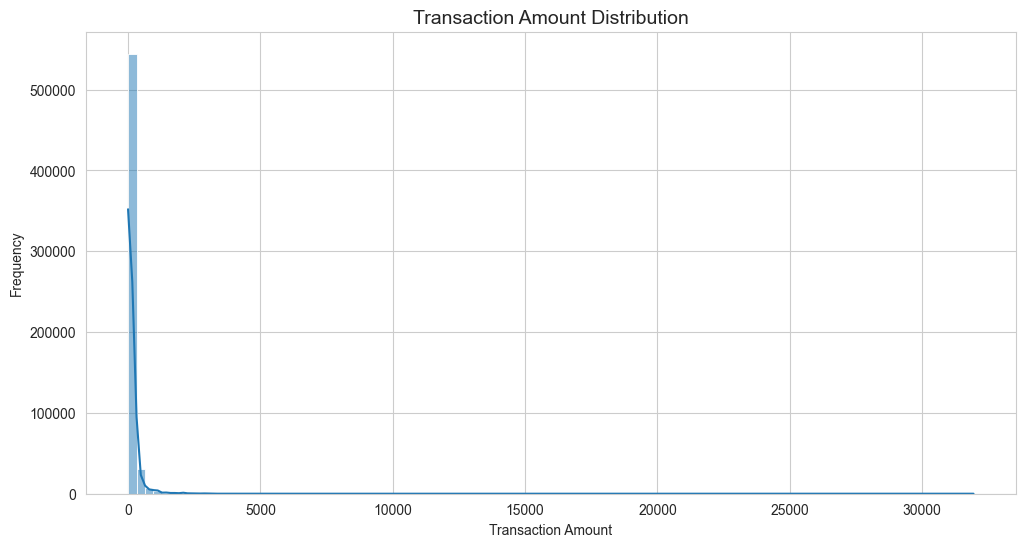

In [27]:
# TRANSACTION AMOUNT DISTRIBUTION

plt.figure(figsize=(12, 6))

sns.histplot(
    df['TransactionAmt'],
    bins=100,
    kde=True
)

plt.title(
    'Transaction Amount Distribution',
    fontsize=14
)

plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')

plt.show()

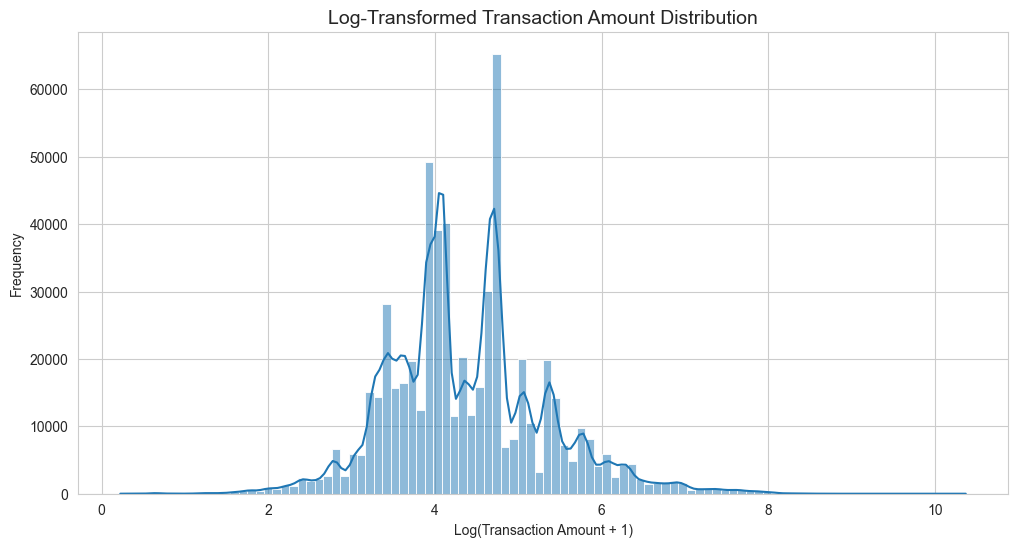

In [28]:
# LOG-TRANSFORMED DISTRIBUTION

plt.figure(figsize=(12, 6))

sns.histplot(
    np.log1p(df['TransactionAmt']),
    bins=100,
    kde=True
)

plt.title(
    'Log-Transformed Transaction Amount Distribution',
    fontsize=14
)

plt.xlabel('Log(Transaction Amount + 1)')
plt.ylabel('Frequency')

plt.show()

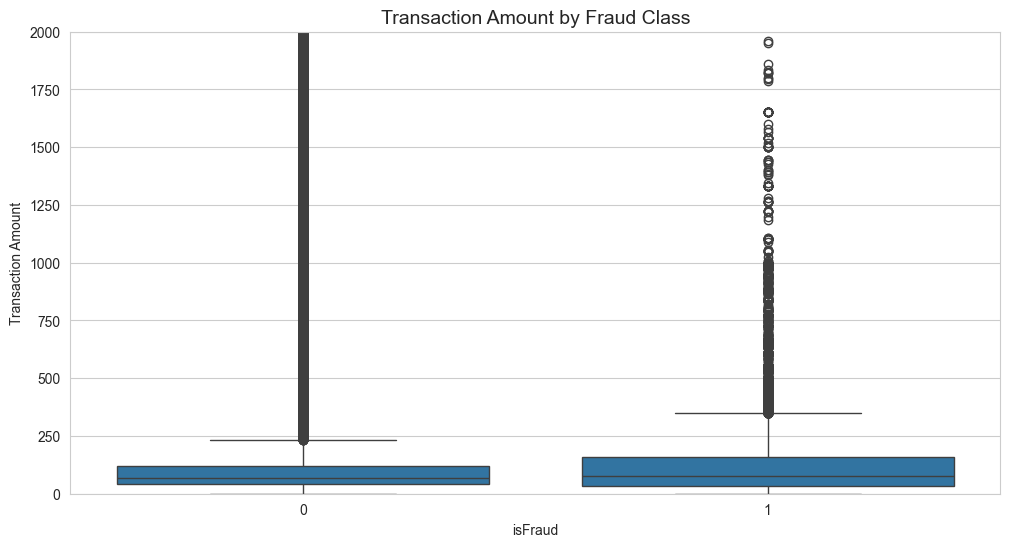

In [29]:
# FRAUD VS LEGIT TRANSACTION AMOUNTS

plt.figure(figsize=(12, 6))

sns.boxplot(
    x='isFraud',
    y='TransactionAmt',
    data=df
)

plt.title(
    'Transaction Amount by Fraud Class',
    fontsize=14
)

plt.xlabel('isFraud')
plt.ylabel('Transaction Amount')

plt.ylim(0, 2000)

plt.show()

In [30]:
# AVERAGE TRANSACTION AMOUNT

df.groupby('isFraud')['TransactionAmt'].mean()

isFraud
0    134.511665
1    149.244779
Name: TransactionAmt, dtype: float64

In [31]:
# TRANSACTION AMOUNT PERCENTILES

df['TransactionAmt'].quantile(
    [0.25, 0.5, 0.75, 0.90, 0.95, 0.99]
)

0.25      43.321
0.50      68.769
0.75     125.000
0.90     275.293
0.95     445.000
0.99    1104.000
Name: TransactionAmt, dtype: float64

### Findings

- Transaction amounts are heavily right-skewed
- Extreme outliers exist in the dataset
- Log transformation significantly improves distribution shape
- Fraudulent transactions show different spending behavior patterns
- Transaction amount will be an important engineered feature

# Time-Based Fraud Analysis

In [32]:
# TRANSACTIONDT SUMMARY

df['TransactionDT'].describe()

count    5.905400e+05
mean     7.372311e+06
std      4.617224e+06
min      8.640000e+04
25%      3.027058e+06
50%      7.306528e+06
75%      1.124662e+07
max      1.581113e+07
Name: TransactionDT, dtype: float64

In [33]:
# APPROXIMATE TRANSACTION HOUR

df['transaction_hour'] = (
    df['TransactionDT'] // 3600
) % 24

df['transaction_hour'].head()

0    0
1    0
2    0
3    0
4    0
Name: transaction_hour, dtype: int64

In [34]:
# FRAUD RATE BY HOUR

hourly_fraud_rate = (
    df.groupby('transaction_hour')['isFraud']
    .mean()
    * 100
)

hourly_fraud_rate

transaction_hour
0      3.137981
1      3.131384
2      3.748317
3      3.831362
4      5.189029
5      7.030203
6      7.774263
7     10.610151
8      9.301428
9      8.995563
10     5.321202
11     3.881646
12     3.043932
13     2.288949
14     2.421632
15     2.539945
16     2.951057
17     3.153009
18     3.523139
19     3.473822
20     3.427313
21     3.400495
22     3.269404
23     3.699717
Name: isFraud, dtype: float64

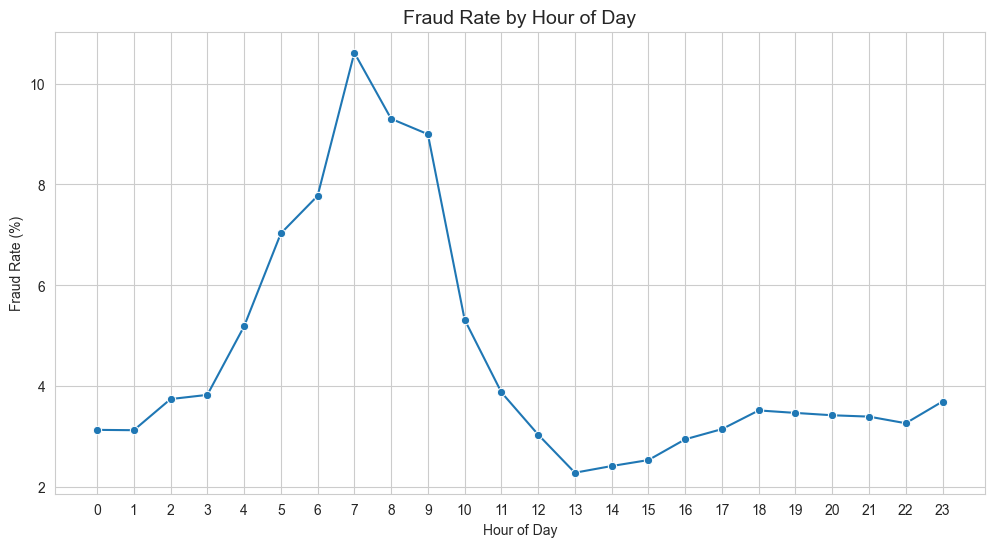

In [35]:
# HOURLY FRAUD RATE PLOT

plt.figure(figsize=(12, 6))

sns.lineplot(
    x=hourly_fraud_rate.index,
    y=hourly_fraud_rate.values,
    marker='o'
)

plt.title(
    'Fraud Rate by Hour of Day',
    fontsize=14
)

plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate (%)')

plt.xticks(range(24))

plt.show()

In [36]:
# APPROXIMATE DAY OF WEEK

df['transaction_day'] = (
    df['TransactionDT'] // (3600 * 24)
) % 7

df['transaction_day'].head()

0    1
1    1
2    1
3    1
4    1
Name: transaction_day, dtype: int64

In [37]:
# FRAUD RATE BY DAY

daily_fraud_rate = (
    df.groupby('transaction_day')['isFraud']
    .mean()
    * 100
)

daily_fraud_rate

transaction_day
0    3.717425
1    3.603988
2    3.711451
3    3.564359
4    3.145155
5    3.304840
6    3.451427
Name: isFraud, dtype: float64

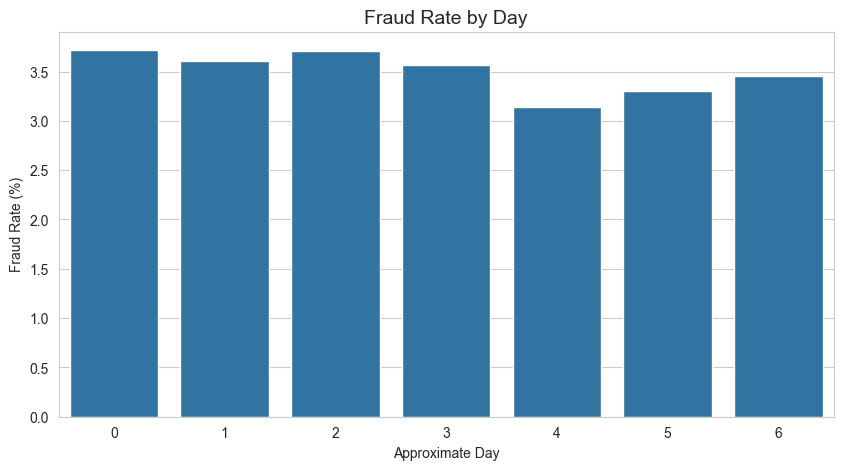

In [38]:
# DAILY FRAUD RATE PLOT

plt.figure(figsize=(10, 5))

sns.barplot(
    x=daily_fraud_rate.index,
    y=daily_fraud_rate.values
)

plt.title(
    'Fraud Rate by Day',
    fontsize=14
)

plt.xlabel('Approximate Day')
plt.ylabel('Fraud Rate (%)')

plt.show()

### Findings

- Fraud activity varies across different hours of the day
- Certain time windows exhibit elevated fraud rates
- Temporal transaction behavior appears predictive
- Time-derived behavioral features may improve fraud detection performance

# Categorical Feature Analysis

In [39]:
# PRODUCTCD DISTRIBUTION

df['ProductCD'].value_counts()

ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64

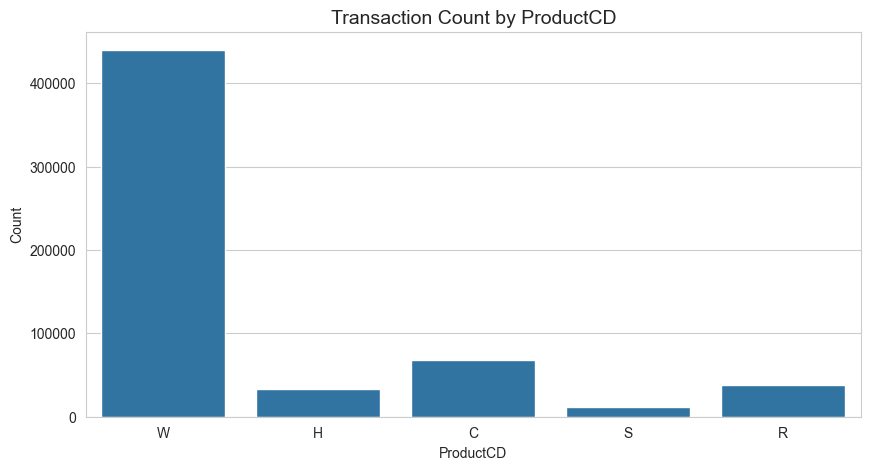

In [40]:
# PRODUCTCD COUNT PLOT

plt.figure(figsize=(10, 5))

sns.countplot(
    x='ProductCD',
    data=df
)

plt.title(
    'Transaction Count by ProductCD',
    fontsize=14
)

plt.xlabel('ProductCD')
plt.ylabel('Count')

plt.show()

In [41]:
# FRAUD RATE BY PRODUCTCD

product_fraud_rate = (
    df.groupby('ProductCD')['isFraud']
    .mean()
    * 100
).sort_values(ascending=False)

product_fraud_rate

ProductCD
C    11.687269
S     5.899553
H     4.766231
R     3.782594
W     2.039939
Name: isFraud, dtype: float64

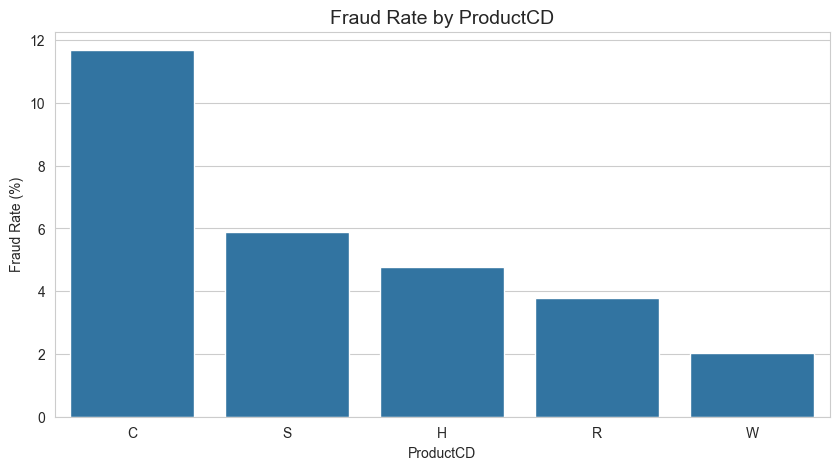

In [42]:
# PRODUCTCD FRAUD RATE PLOT

plt.figure(figsize=(10, 5))

sns.barplot(
    x=product_fraud_rate.index,
    y=product_fraud_rate.values
)

plt.title(
    'Fraud Rate by ProductCD',
    fontsize=14
)

plt.xlabel('ProductCD')
plt.ylabel('Fraud Rate (%)')

plt.show()

In [43]:
# CARD BRAND DISTRIBUTION

df['card4'].value_counts()

card4
visa                384767
mastercard          189217
american express      8328
discover              6651
Name: count, dtype: int64

In [44]:
# Fraud Rate By Card Brand

card4_fraud_rate = (
    df.groupby('card4')['isFraud']
    .mean()
    * 100
).sort_values(ascending=False)

card4_fraud_rate

card4
discover            7.728161
visa                3.475610
mastercard          3.433095
american express    2.869837
Name: isFraud, dtype: float64

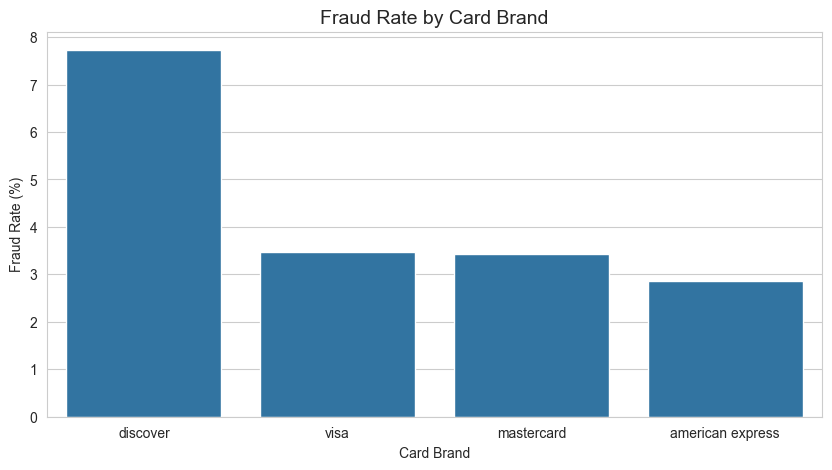

In [45]:
# CARD BRAND FRAUD RATE PLOT

plt.figure(figsize=(10, 5))

sns.barplot(
    x=card4_fraud_rate.index,
    y=card4_fraud_rate.values
)

plt.title(
    'Fraud Rate by Card Brand',
    fontsize=14
)

plt.xlabel('Card Brand')
plt.ylabel('Fraud Rate (%)')

plt.show()

In [46]:
# CARD TYPE DISTRIBUTION

df['card6'].value_counts()

card6
debit              439938
credit             148986
debit or credit        30
charge card            15
Name: count, dtype: int64

In [47]:
# FRAUD RATE BY CARD TYPE

card6_fraud_rate = (
    df.groupby('card6')['isFraud']
    .mean()
    * 100
).sort_values(ascending=False)

card6_fraud_rate

card6
credit             6.678480
debit              2.426251
charge card        0.000000
debit or credit    0.000000
Name: isFraud, dtype: float64

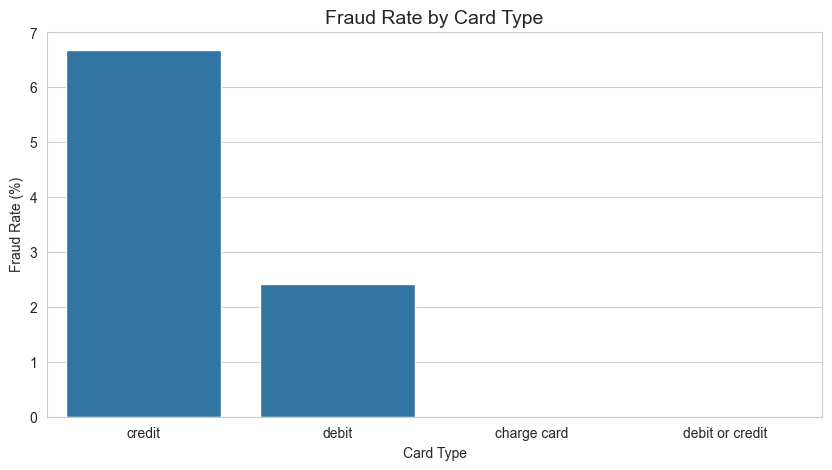

In [48]:
# CARD TYPE FRAUD RATE PLOT

plt.figure(figsize=(10, 5))

sns.barplot(
    x=card6_fraud_rate.index,
    y=card6_fraud_rate.values
)

plt.title(
    'Fraud Rate by Card Type',
    fontsize=14
)

plt.xlabel('Card Type')
plt.ylabel('Fraud Rate (%)')

plt.show()

### Findings

- Fraud rates vary significantly across product categories
- Certain payment types exhibit elevated fraud risk
- Card brand and card type appear behaviorally informative
- Categorical transaction metadata contains predictive fraud signals

# Email Domain Analysis

In [49]:
# TOP PURCHASER EMAIL DOMAINS

df['P_emaildomain'].value_counts().head(10)

P_emaildomain
gmail.com        228355
yahoo.com        100934
hotmail.com       45250
anonymous.com     36998
aol.com           28289
comcast.net        7888
icloud.com         6267
outlook.com        5096
msn.com            4092
att.net            4033
Name: count, dtype: int64

In [50]:
# FRAUD RATE BY PURCHASER EMAIL DOMAIN

email_fraud_rate = (
    df.groupby('P_emaildomain')['isFraud']
    .mean()
    * 100
)

top_email_fraud = email_fraud_rate.sort_values(
    ascending=False
).head(10)

top_email_fraud

P_emaildomain
protonmail.com    40.789474
mail.com          18.962433
outlook.es        13.013699
aim.com           12.698413
outlook.com        9.458399
hotmail.es         6.557377
live.com.mx        5.473965
hotmail.com        5.295028
gmail.com          4.354185
yahoo.fr           3.496503
Name: isFraud, dtype: float64

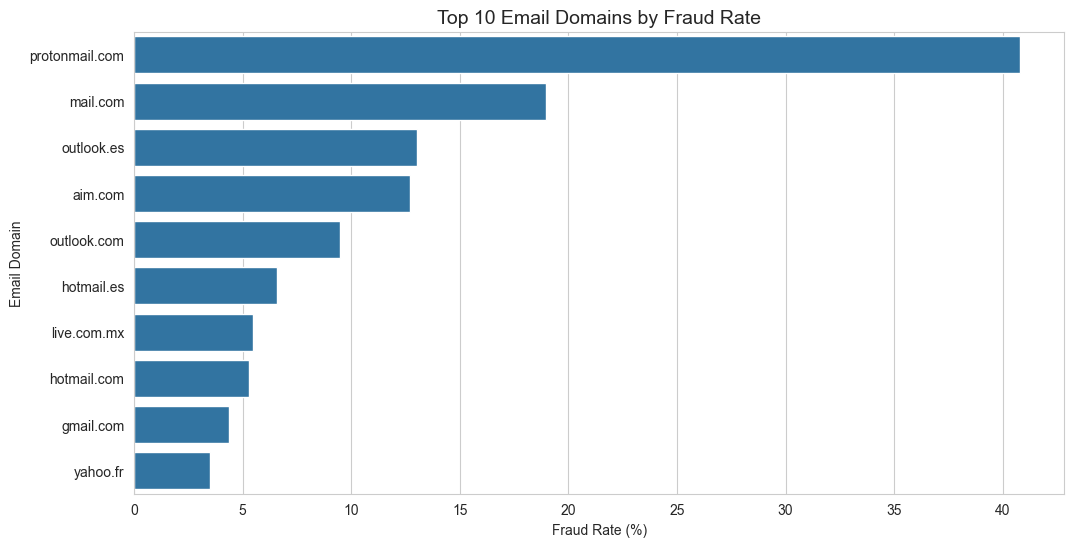

In [51]:
# EMAIL DOMAIN FRAUD RATE PLOT

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_email_fraud.values,
    y=top_email_fraud.index
)

plt.title(
    'Top 10 Email Domains by Fraud Rate',
    fontsize=14
)

plt.xlabel('Fraud Rate (%)')
plt.ylabel('Email Domain')

plt.show()

In [52]:
# MISSING EMAIL DOMAIN ANALYSIS

missing_email_rate = (
    df['P_emaildomain']
    .isnull()
    .mean()
    * 100
)

print(f"Missing Purchaser Email Domains: {missing_email_rate:.2f}%")

Missing Purchaser Email Domains: 15.99%


In [53]:
# FRAUD RATE: MISSING VS NON-MISSING EMAILS

df['email_missing'] = df['P_emaildomain'].isnull()

email_missing_fraud = (
    df.groupby('email_missing')['isFraud']
    .mean()
    * 100
)

email_missing_fraud

email_missing
False    3.602817
True     2.953756
Name: isFraud, dtype: float64

In [54]:
# EMAIL DOMAIN MATCH ANALYSIS

df['email_match'] = (
    df['P_emaildomain']
    == df['R_emaildomain']
)

email_match_fraud = (
    df.groupby('email_match')['isFraud']
    .mean()
    * 100
)

email_match_fraud

email_match
False    2.207009
True     9.650355
Name: isFraud, dtype: float64

### Findings

- Fraud rates vary across email providers
- Missing email information may contain predictive signals
- Email-domain mismatches may correlate with suspicious behavior
- Email metadata appears behaviorally informative for fraud detection

# C-Feature Analysis

In [55]:
# C-FEATURE SUMMARY

c_features = [
    col for col in df.columns
    if col.startswith('C')
]

df[c_features].describe()

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14
count,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000
mean,14.092458,15.269734,0.005644,4.092185,5.571526,9.071082,2.848478,5.144574,4.480240,5.240343,10.241521,4.076227,32.539918,8.295215
std,133.569018,154.668899,0.150536,68.848459,25.786976,71.508467,61.727304,95.378574,16.674897,95.581443,94.336292,86.666218,129.364844,49.544262
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
50%,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,1.000000
75%,3.000000,3.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,2.000000,0.000000,2.000000,0.000000,12.000000,2.000000
max,4685.000000,5691.000000,26.000000,2253.000000,349.000000,2253.000000,2255.000000,3331.000000,210.000000,3257.000000,3188.000000,3188.000000,2918.000000,1429.000000


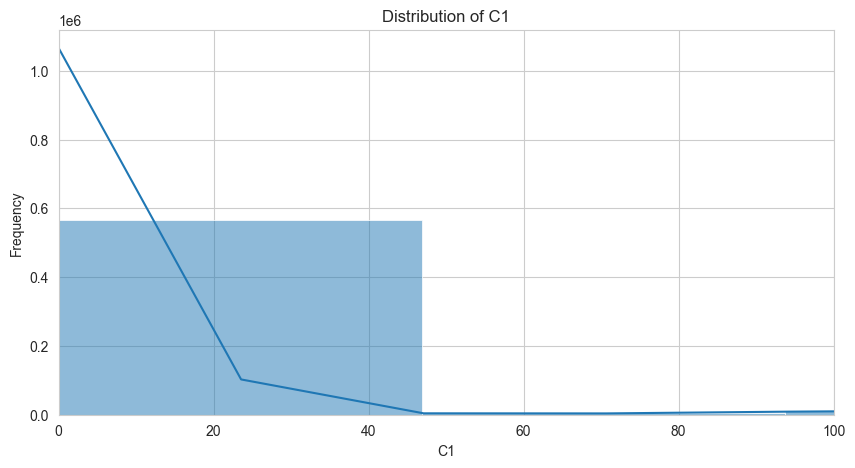

In [56]:
# C1 DISTRIBUTION

plt.figure(figsize=(10, 5))

sns.histplot(
    df['C1'],
    bins=100,
    kde=True
)

plt.title('Distribution of C1')
plt.xlabel('C1')
plt.ylabel('Frequency')

plt.xlim(0, 100)

plt.show()

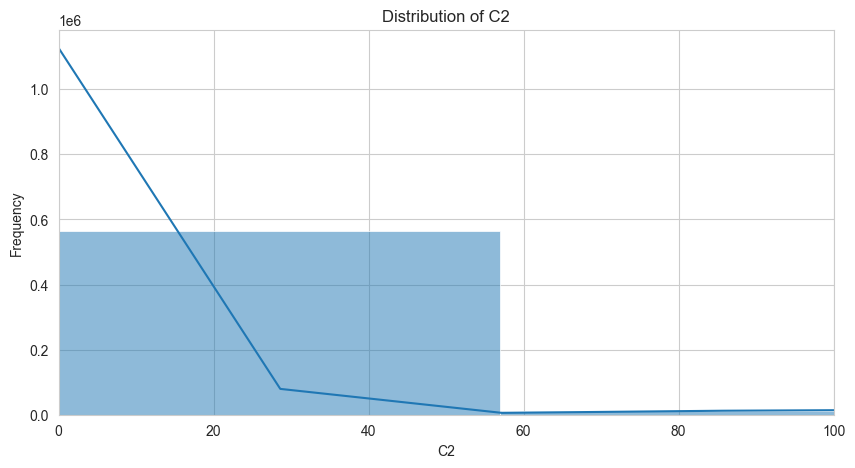

In [57]:
# C2 DISTRIBUTION

plt.figure(figsize=(10, 5))

sns.histplot(
    df['C2'],
    bins=100,
    kde=True
)

plt.title('Distribution of C2')
plt.xlabel('C2')
plt.ylabel('Frequency')

plt.xlim(0, 100)

plt.show()

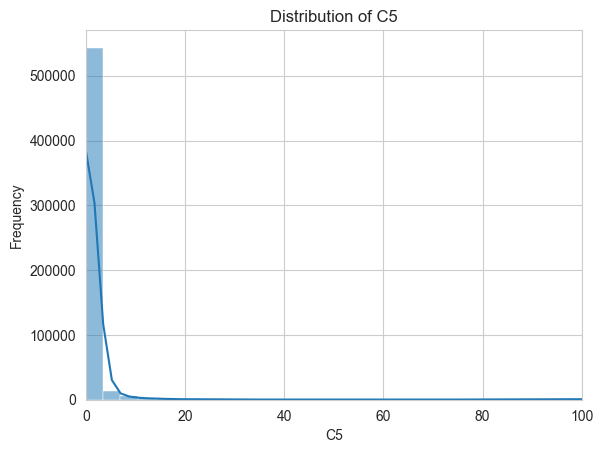

In [58]:
# c5 DISTRIBUTION

plt.Figure(figsize=(10,5))

sns.histplot(
    df['C5'],
    bins=100,
    kde=True
)

plt.title('Distribution of C5')
plt.xlabel('C5')
plt.ylabel('Frequency')

plt.xlim(0, 100)

plt.show()

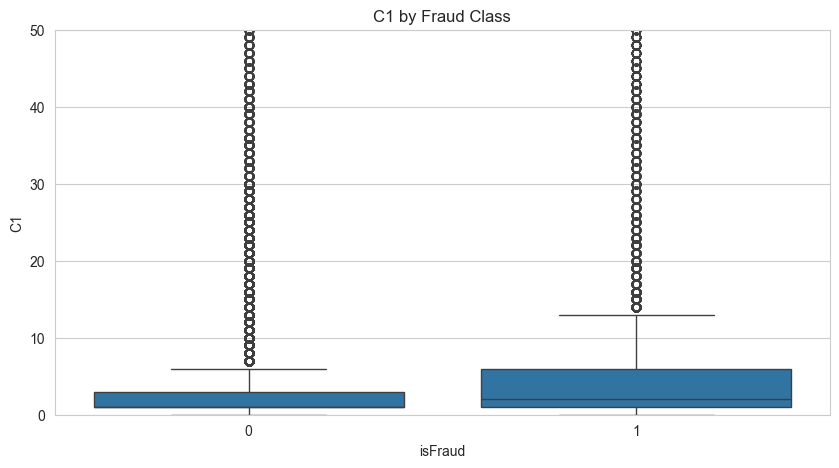

In [59]:
# C1 VS FRAUD

plt.figure(figsize=(10, 5))

sns.boxplot(
    x='isFraud',
    y='C1',
    data=df
)

plt.title('C1 by Fraud Class')
plt.xlabel('isFraud')
plt.ylabel('C1')

plt.ylim(0, 50)

plt.show()

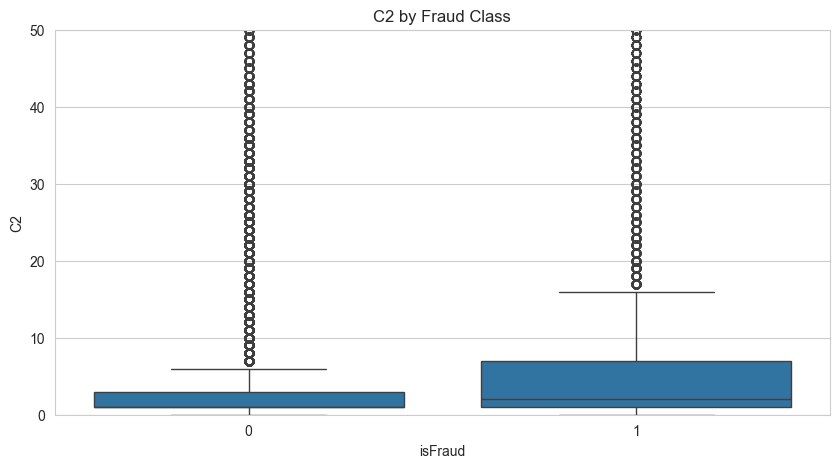

In [60]:
# C2 VS FRAUD

plt.figure(figsize=(10, 5))

sns.boxplot(
    x='isFraud',
    y='C2',
    data=df
)

plt.title('C2 by Fraud Class')
plt.xlabel('isFraud')
plt.ylabel('C2')

plt.ylim(0, 50)

plt.show()

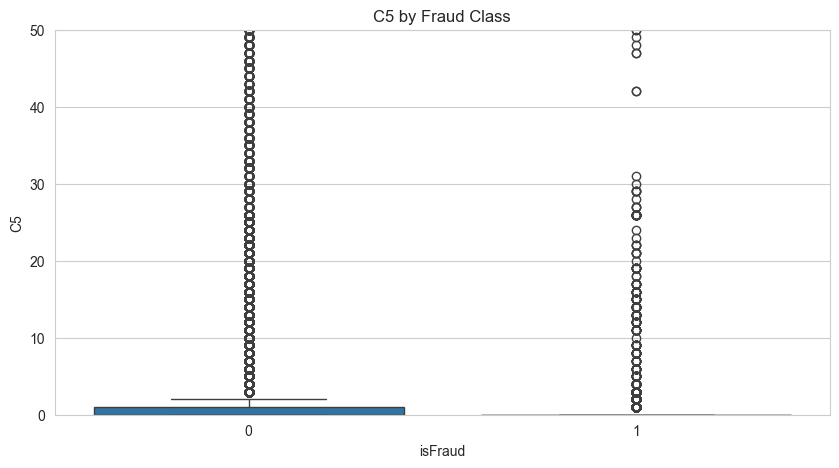

In [61]:
# C5 VS FRAUD

plt.figure(figsize=(10, 5))

sns.boxplot(
    x='isFraud',
    y='C5',
    data=df
)

plt.title('C5 by Fraud Class')
plt.xlabel('isFraud')   
plt.ylabel('C5')

plt.ylim(0, 50)
plt.show()

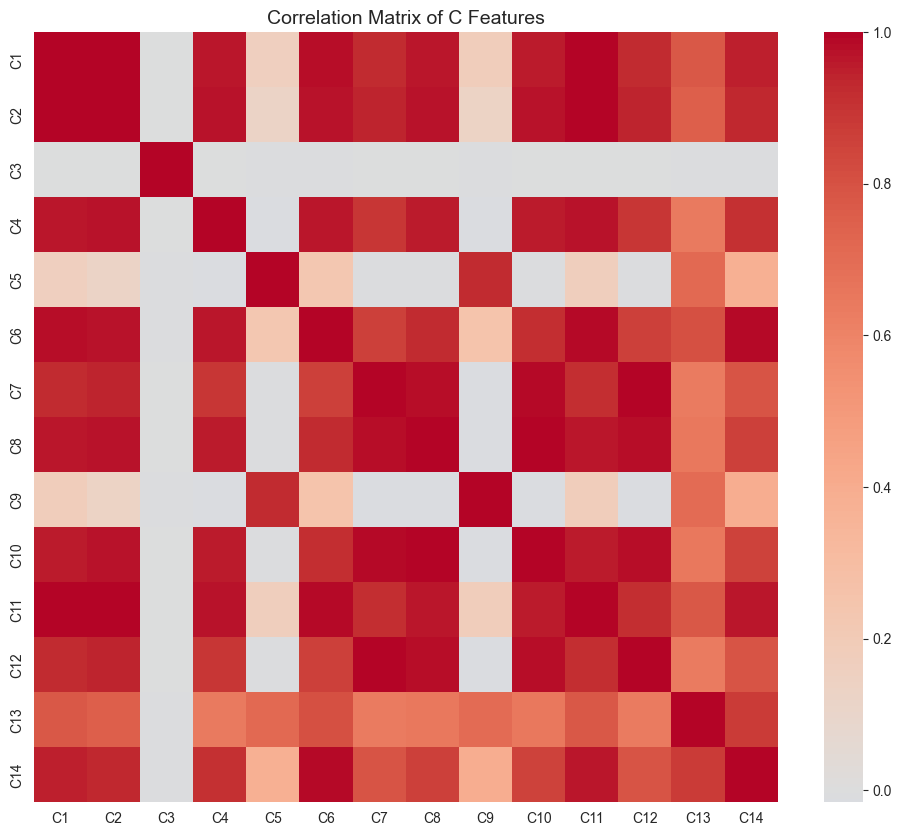

In [62]:
# C-FEATURE CORRELATION MATRIX

plt.figure(figsize=(12, 10))

corr_matrix = df[c_features].corr()

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0
)

plt.title(
    'Correlation Matrix of C Features',
    fontsize=14
)

plt.show()

### Findings

- C-features exhibit heavily skewed behavioral count distributions
- Fraudulent transactions show different count behavior patterns
- Several C-features appear strongly correlated
- Behavioral frequency signals may be highly predictive for fraud detection

# V-Feature Analysis

In [63]:
# IDENTIFY V FEATURES

v_features = [
    col for col in df.columns
    if col.startswith('V')
]

print(f"Number of V Features: {len(v_features)}")

Number of V Features: 339


In [64]:
# V-FEATURE MISSINGNESS

v_missing = (
    df[v_features]
    .isnull()
    .mean()
    * 100
).sort_values(ascending=False)

v_missing.head(20)

V142    86.123717
V149    86.123717
V157    86.123717
V156    86.123717
V155    86.123717
V154    86.123717
V153    86.123717
V161    86.123717
V162    86.123717
V163    86.123717
V148    86.123717
V147    86.123717
V146    86.123717
V138    86.123717
V139    86.123717
V140    86.123717
V141    86.123717
V158    86.123717
V160    86.122701
V164    86.122701
dtype: float64

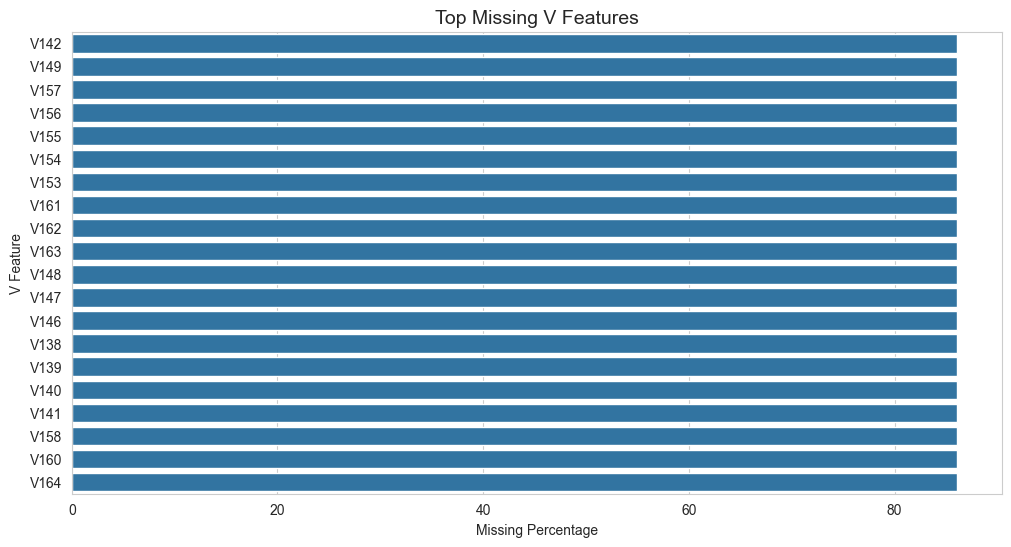

In [65]:
# TOP V-FEATURE MISSINGNESS

plt.figure(figsize=(12, 6))

sns.barplot(
    x=v_missing.head(20).values,
    y=v_missing.head(20).index
)

plt.title(
    'Top Missing V Features',
    fontsize=14
)

plt.xlabel('Missing Percentage')
plt.ylabel('V Feature')

plt.show()

In [66]:
# V-FEATURE STATISTICS

df[v_features].describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
V1,311253.0,0.999945,0.007390,0.0,1.0,1.0,1.0,1.0
V2,311253.0,1.045204,0.240133,0.0,1.0,1.0,1.0,8.0
V3,311253.0,1.078075,0.320890,0.0,1.0,1.0,1.0,9.0
V4,311253.0,0.846456,0.440053,0.0,1.0,1.0,1.0,6.0
V5,311253.0,0.876991,0.475902,0.0,1.0,1.0,1.0,6.0
V6,311253.0,1.045686,0.239385,0.0,1.0,1.0,1.0,9.0
V7,311253.0,1.072870,0.304779,0.0,1.0,1.0,1.0,9.0
V8,311253.0,1.027704,0.186069,0.0,1.0,1.0,1.0,8.0
V9,311253.0,1.041529,0.226339,0.0,1.0,1.0,1.0,8.0
V10,311253.0,0.463915,0.521522,0.0,0.0,0.0,1.0,4.0


In [67]:
# V-FEATURE CORRELATION WITH TARGET

v_target_corr = (
    df[v_features]
    .corrwith(df['isFraud'])
    .abs()
    .sort_values(ascending=False)
)

v_target_corr.head(20)

V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005
V200    0.318783
V189    0.308219
V188    0.303582
V258    0.297151
V45     0.281832
V158    0.278066
V156    0.275952
V149    0.273282
V228    0.268861
V44     0.260376
V86     0.251828
V87     0.251737
V170    0.249794
V147    0.242894
V52     0.239469
dtype: float64

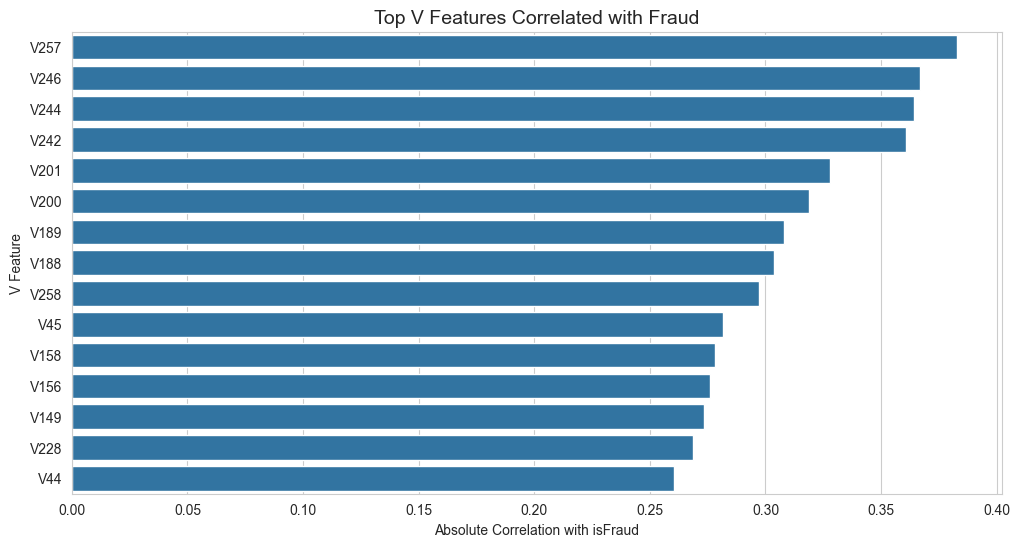

In [68]:
# TOP V-FEATURE CORRELATIONS

top_v_corr = v_target_corr.head(15)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_v_corr.values,
    y=top_v_corr.index
)

plt.title(
    'Top V Features Correlated with Fraud',
    fontsize=14
)

plt.xlabel('Absolute Correlation with isFraud')
plt.ylabel('V Feature')

plt.show()

Top Correlated V Feature: V257


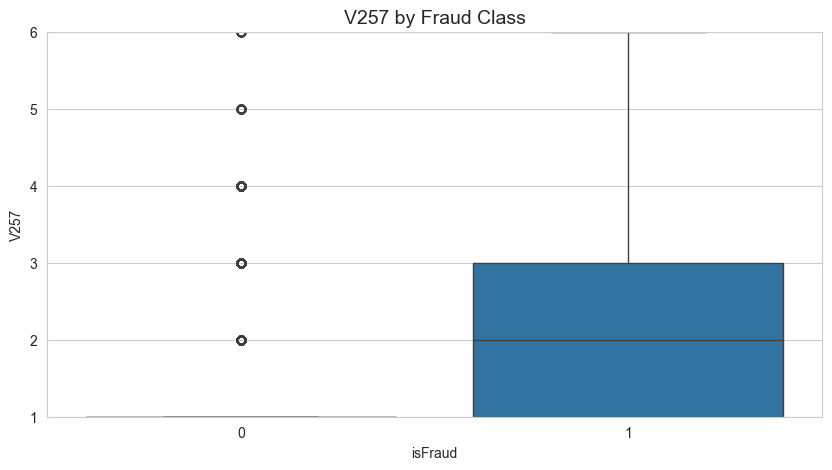

In [69]:
# TOP V FEATURE DISTRIBUTION

top_v_feature = v_target_corr.index[0]

print("Top Correlated V Feature:", top_v_feature)

plt.figure(figsize=(10, 5))

sns.boxplot(
    x='isFraud',
    y=top_v_feature,
    data=df
)

plt.title(
    f'{top_v_feature} by Fraud Class',
    fontsize=14
)

plt.ylim(
    df[top_v_feature].quantile(0.01),
    df[top_v_feature].quantile(0.99)
)

plt.show()

### Findings

- V-features contain substantial engineered behavioral information
- Many V-features exhibit moderate missingness and strong variance
- Several V-features show meaningful correlation with fraud labels
- Engineered behavioral vectors are likely major predictive drivers

# D-Feature Analysis

In [76]:
# IDENTIFY D FEATURES

d_features = [
    col for col in df.columns
    if col.startswith('D') and col[1:].isdigit()
]

print(d_features)
print(f"Number of D Features: {len(d_features)}")

['D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15']
Number of D Features: 15


In [77]:
# D-FEATURE MISSINGNESS

d_missing = (
    df[d_features]
    .isnull()
    .mean()
    * 100
).sort_values(ascending=False)

d_missing

D7     93.409930
D13    89.509263
D14    89.469469
D12    89.041047
D6     87.606767
D8     87.312290
D9     87.312290
D5     52.467403
D2     47.549192
D11    47.293494
D3     44.514851
D4     28.604667
D15    15.090087
D10    12.873302
D1      0.214888
dtype: float64

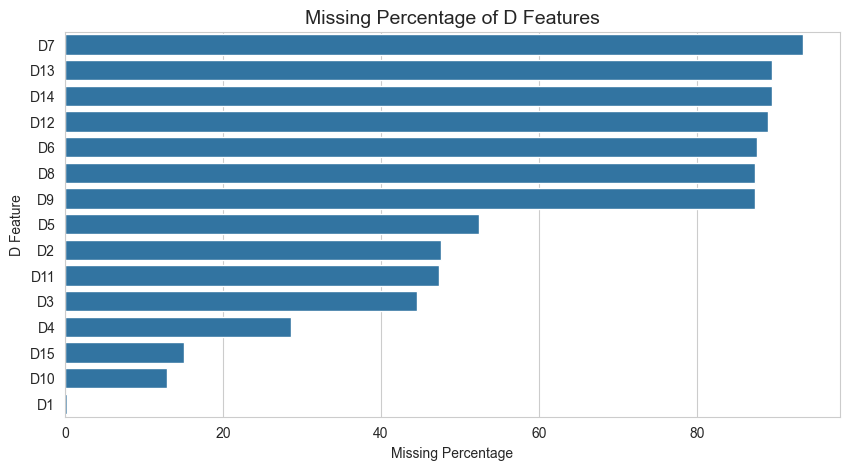

In [78]:
# D-FEATURE MISSINGNESS PLOT

plt.figure(figsize=(10, 5))

sns.barplot(
    x=d_missing.values,
    y=d_missing.index
)

plt.title(
    'Missing Percentage of D Features',
    fontsize=14
)

plt.xlabel('Missing Percentage')
plt.ylabel('D Feature')

plt.show()

In [79]:
# D-FEATURE STATISTICS

df[d_features].describe().T

,count,mean,std,min,25%,50%,75%,max
D1,589271.0,94.347568,157.660387,0.0,0.000000,3.000000,122.000000,640.000000
D2,309743.0,169.563231,177.315865,0.0,26.000000,97.000000,276.000000,640.000000
D3,327662.0,28.343348,62.384721,0.0,1.000000,8.000000,27.000000,819.000000
D4,421618.0,140.002441,191.096774,-122.0,0.000000,26.000000,253.000000,869.000000
D5,280699.0,42.335965,89.000144,0.0,1.000000,10.000000,32.000000,819.000000
D6,73187.0,69.805717,143.669253,-83.0,0.000000,0.000000,40.000000,873.000000
D7,38917.0,41.638950,99.743264,0.0,0.000000,0.000000,17.000000,843.000000
D8,74926.0,146.058108,231.663840,0.0,0.958333,37.875000,187.958328,1707.791626
D9,74926.0,0.561057,0.316880,0.0,0.208333,0.666666,0.833333,0.958333
D10,514518.0,123.982137,182.615225,0.0,0.000000,15.000000,197.000000,876.000000


In [80]:
# D-FEATURE CORRELATION WITH TARGET

d_target_corr = (
    df[d_features]
    .corrwith(df['isFraud'])
    .abs()
    .sort_values(ascending=False)
)

d_target_corr

D8     0.142636
D7     0.127199
D2     0.083583
D15    0.077519
D10    0.072002
D4     0.067216
D1     0.067193
D5     0.064638
D13    0.059430
D6     0.057236
D3     0.046271
D11    0.045094
D9     0.044253
D12    0.028864
D14    0.008663
dtype: float64

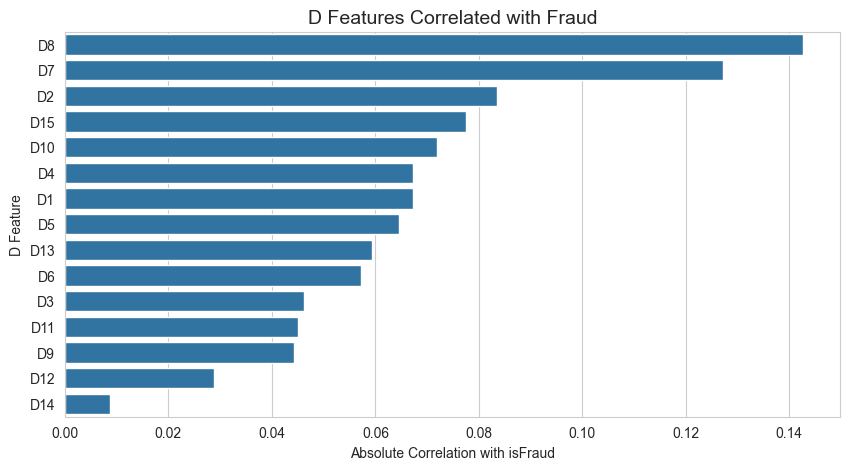

In [81]:
# TOP D-FEATURE CORRELATIONS

plt.figure(figsize=(10, 5))

sns.barplot(
    x=d_target_corr.values,
    y=d_target_corr.index
)

plt.title(
    'D Features Correlated with Fraud',
    fontsize=14
)

plt.xlabel('Absolute Correlation with isFraud')
plt.ylabel('D Feature')

plt.show()

Top D Feature: D8


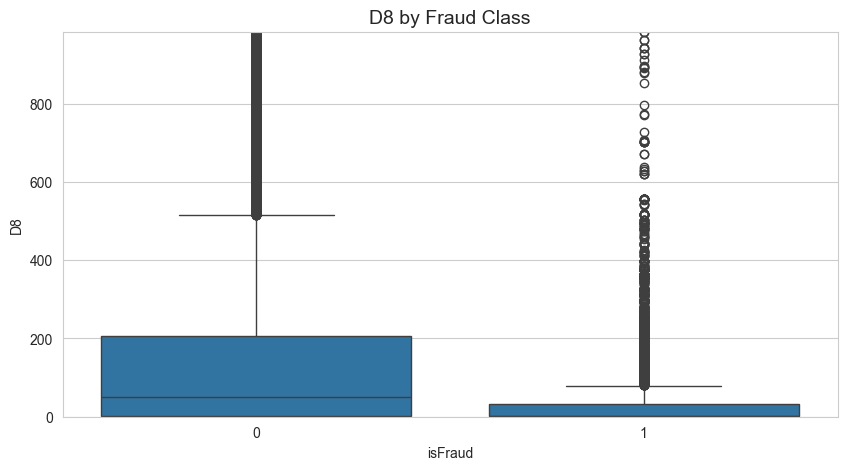

In [82]:
# TOP D FEATURE BOXPLOT

top_d_feature = d_target_corr.index[0]

print("Top D Feature:", top_d_feature)

plt.figure(figsize=(10, 5))

sns.boxplot(
    x='isFraud',
    y=top_d_feature,
    data=df
)

plt.title(
    f'{top_d_feature} by Fraud Class',
    fontsize=14
)

plt.ylim(
    df[top_d_feature].quantile(0.01),
    df[top_d_feature].quantile(0.99)
)

plt.show()

### Findings

- D-features contain substantial temporal behavioral information
- Missingness is high across several D-features
- Certain D-features show measurable fraud correlation
- Timing-gap behavior appears informative for fraud detection

# M-Feature Analysis

In [83]:
# IDENTIFY M FEATURES

m_features = [
    col for col in df.columns
    if col.startswith('M') and len(col) <= 2
]

print(m_features)
print(f"Number of M Features: {len(m_features)}")

['M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']
Number of M Features: 9


In [84]:
# UNIQUE VALUES OF M FEATURES

for col in m_features:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


M1
M1
T      319415
NaN    271100
F          25
Name: count, dtype: int64

M2
M2
T      285468
NaN    271100
F       33972
Name: count, dtype: int64

M3
M3
NaN    271100
T      251731
F       67709
Name: count, dtype: int64

M4
M4
NaN    281444
M0     196405
M2      59865
M1      52826
Name: count, dtype: int64

M5
M5
NaN    350482
F      132491
T      107567
Name: count, dtype: int64

M6
M6
F      227856
T      193324
NaN    169360
Name: count, dtype: int64

M7
M7
NaN    346265
F      211374
T       32901
Name: count, dtype: int64

M8
M8
NaN    346252
F      155251
T       89037
Name: count, dtype: int64

M9
M9
NaN    346252
T      205656
F       38632
Name: count, dtype: int64


In [85]:
# FRAUD RATE BY M FEATURE VALUES

for col in m_features:
    print(f"\nFraud Rate for {col}")
    
    fraud_rate = (
        df.groupby(col)['isFraud']
        .mean()
        * 100
    )
    
    print(fraud_rate)


Fraud Rate for M1
M1
F    0.000000
T    1.985505
Name: isFraud, dtype: float64

Fraud Rate for M2
M2
F    3.485223
T    1.806858
Name: isFraud, dtype: float64

Fraud Rate for M3
M3
F    3.026186
T    1.705392
Name: isFraud, dtype: float64

Fraud Rate for M4
M4
M0     3.664876
M1     2.705107
M2    11.373925
Name: isFraud, dtype: float64

Fraud Rate for M5
M5
F    2.652256
T    3.769744
Name: isFraud, dtype: float64

Fraud Rate for M6
M6
F    2.368601
T    1.704393
Name: isFraud, dtype: float64

Fraud Rate for M7
M7
F    1.934486
T    2.212699
Name: isFraud, dtype: float64

Fraud Rate for M8
M8
F    2.172611
T    1.621798
Name: isFraud, dtype: float64

Fraud Rate for M9
M9
F    3.000104
T    1.778698
Name: isFraud, dtype: float64


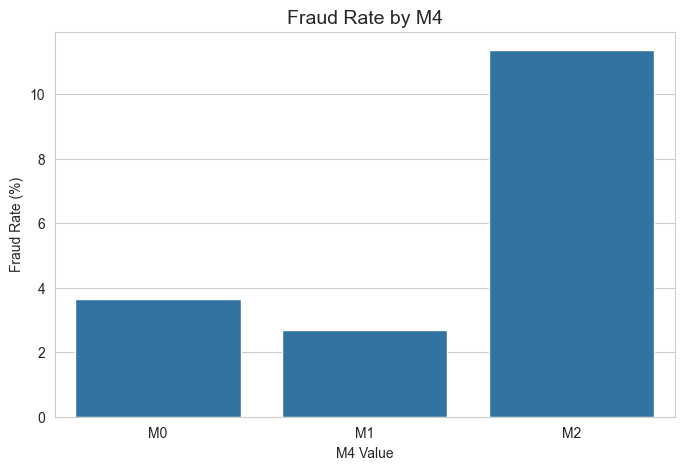

In [86]:
# M4 FRAUD RATE VISUALIZATION

m4_fraud = (
    df.groupby('M4')['isFraud']
    .mean()
    * 100
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=m4_fraud.index.astype(str),
    y=m4_fraud.values
)

plt.title(
    'Fraud Rate by M4',
    fontsize=14
)

plt.xlabel('M4 Value')
plt.ylabel('Fraud Rate (%)')

plt.show()

In [87]:
# M-FEATURE MISSINGNESS

m_missing = (
    df[m_features]
    .isnull()
    .mean()
    * 100
).sort_values(ascending=False)

m_missing

M5    59.349409
M7    58.635317
M8    58.633115
M9    58.633115
M4    47.658753
M1    45.907136
M2    45.907136
M3    45.907136
M6    28.678836
dtype: float64

In [88]:
# ENCODE M FEATURES

m_encoded = df[m_features].copy()

for col in m_encoded.columns:
    m_encoded[col] = m_encoded[col].map({
        'T': 1,
        'F': 0
    })

m_encoded.head()

,M1,M2,M3,M4,M5,M6,M7,M8,M9
0,1.0,1.0,1.0,NaN,0.0,1.0,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN
2,1.0,1.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0
3,NaN,NaN,NaN,NaN,1.0,0.0,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [89]:
# M-FEATURE CORRELATION WITH TARGET

m_target_corr = (
    m_encoded
    .corrwith(df['isFraud'])
    .abs()
    .sort_values(ascending=False)
)

m_target_corr

M3    0.038697
M2    0.037091
M9    0.032055
M5    0.031802
M6    0.023282
M8    0.019067
M7    0.006831
M1    0.001259
M4         NaN
dtype: float64

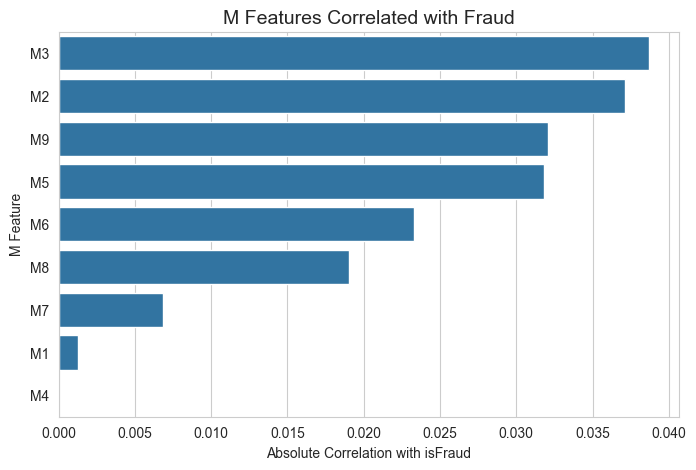

In [90]:
# M-FEATURE CORRELATION PLOT

plt.figure(figsize=(8, 5))

sns.barplot(
    x=m_target_corr.values,
    y=m_target_corr.index
)

plt.title(
    'M Features Correlated with Fraud',
    fontsize=14
)

plt.xlabel('Absolute Correlation with isFraud')
plt.ylabel('M Feature')

plt.show()

### Findings

- M-features encode identity and consistency-related behavioral signals
- Certain match indicators exhibit elevated fraud rates
- Missingness is substantial across several M-features
- Identity consistency appears predictive for fraud detection

# Correlation & Feature Importance Overview

In [93]:
# NUMERICAL FEATURE CORRELATION WITH TARGET
# Memory-efficient approach: process correlations without consolidating

# Get numerical column names without loading data
numeric_cols = df.dtypes[df.dtypes.isin(['int64', 'float64'])].index.tolist()

# Remove isFraud if it's in the list (we'll add it back at the end)
numeric_cols = [col for col in numeric_cols if col != 'isFraud']

print(f"Processing {len(numeric_cols)} numerical features...")

# Calculate correlations directly without select_dtypes()
target_corr = pd.Series(
    [df[col].corr(df['isFraud']) for col in numeric_cols],
    index=numeric_cols
).abs().sort_values(ascending=False)

target_corr.head(20)

Processing 404 numerical features...


V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005
V200    0.318783
V189    0.308219
V188    0.303582
V258    0.297151
V45     0.281832
V158    0.278066
V156    0.275952
V149    0.273282
V228    0.268861
V44     0.260376
V86     0.251828
V87     0.251737
V170    0.249794
V147    0.242894
V52     0.239469
dtype: float64

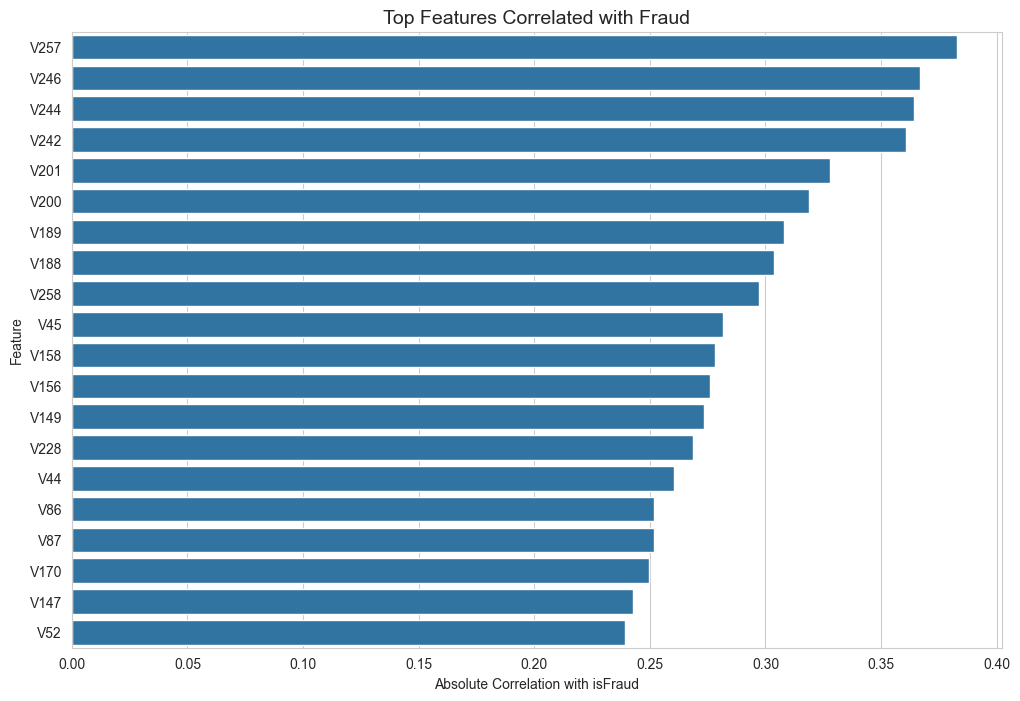

In [94]:
# TOP FEATURE CORRELATIONS
top_corr = target_corr.head(20)

plt.figure(figsize=(12, 8))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title(
    'Top Features Correlated with Fraud',
    fontsize=14
)

plt.xlabel('Absolute Correlation with isFraud')
plt.ylabel('Feature')

plt.show()

In [95]:
# FEATURE GROUP CONTRIBUTION

feature_groups = {
    'V Features': v_features,
    'C Features': c_features,
    'D Features': d_features,
    'M Features': m_features
}

group_max_corr = {}

for group, cols in feature_groups.items():
    
    valid_cols = [
        col for col in cols
        if col in target_corr.index
    ]
    
    group_max_corr[group] = (
        target_corr[valid_cols]
        .max()
    )

group_corr_df = pd.DataFrame({
    'Feature Group': group_max_corr.keys(),
    'Max Correlation': group_max_corr.values()
})

group_corr_df

,Feature Group,Max Correlation
0,V Features,0.383060
1,C Features,0.037229
2,D Features,0.142636
3,M Features,NaN


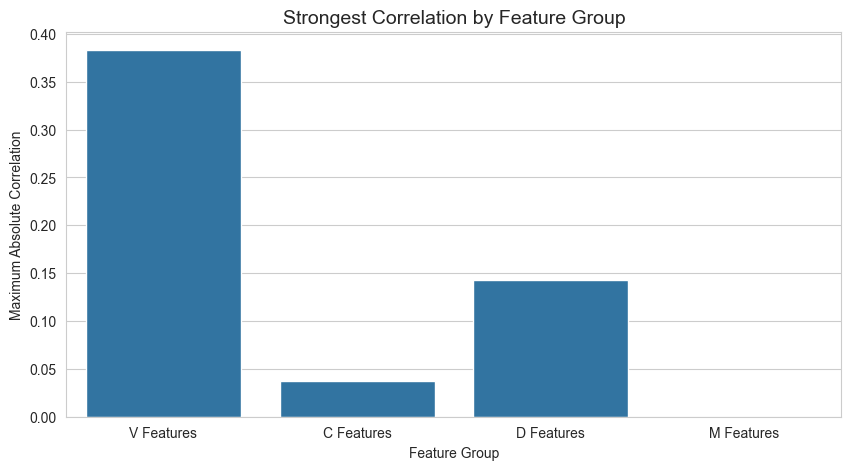

In [96]:
# FEATURE GROUP STRENGTH

plt.figure(figsize=(10, 5))

sns.barplot(
    x='Feature Group',
    y='Max Correlation',
    data=group_corr_df
)

plt.title(
    'Strongest Correlation by Feature Group',
    fontsize=14
)

plt.ylabel('Maximum Absolute Correlation')
plt.xlabel('Feature Group')

plt.show()

In [98]:
# FEATURE-TO-FEATURE CORRELATION (Memory-Efficient)
# Only check top correlated features for multicollinearity

# Select top 50 features by correlation with target
top_50_features = target_corr.head(50).index.tolist()

print(f"Computing correlations for top {len(top_50_features)} features...")

# Calculate correlation matrix only for top features
top_features_df = df[top_50_features].dropna(axis=1, how='all')

corr_matrix = top_features_df.corr().abs()

# Find highly correlated feature pairs
upper_triangle = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

high_corr_pairs = []

for column in upper_triangle.columns:
    high_corr_vals = upper_triangle[column][upper_triangle[column] > 0.95]
    if len(high_corr_vals) > 0:
        for idx, val in high_corr_vals.items():
            high_corr_pairs.append({
                'Feature 1': column,
                'Feature 2': idx,
                'Correlation': val
            })

high_corr_df = pd.DataFrame(high_corr_pairs)

print(f"\nHighly correlated pairs (>0.95): {len(high_corr_df)}")

high_corr_df.head(10)

Computing correlations for top 50 features...

Highly correlated pairs (>0.95): 19


,Feature 1,Feature 2,Correlation
0,V242,V244,0.974318
1,V149,V156,0.976168
2,V157,V158,0.954520
3,V155,V156,0.953647
4,V148,V149,0.950232
5,V148,V155,0.975978
6,V51,V52,0.952022
7,V190,V199,0.955218
8,V42,V43,0.952002
9,V94,V51,0.950989


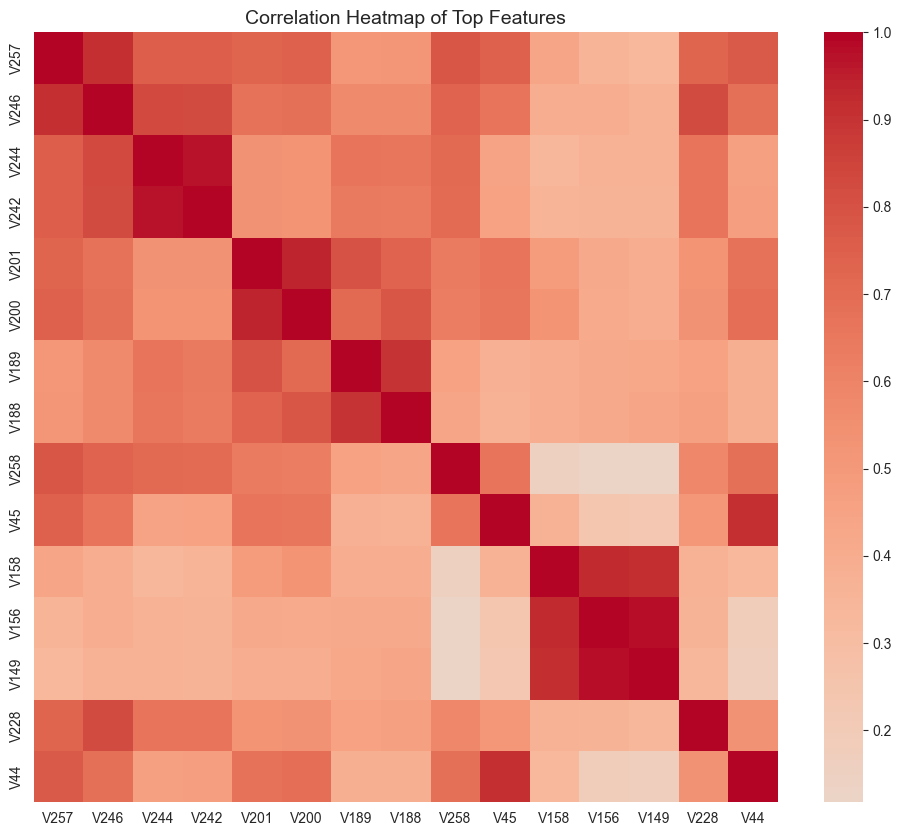

In [99]:
# HEATMAP OF TOP FEATURES

top_feature_names = target_corr.head(15).index

plt.figure(figsize=(12, 10))

sns.heatmap(
    df[top_feature_names].corr(),
    cmap='coolwarm',
    center=0
)

plt.title(
    'Correlation Heatmap of Top Features',
    fontsize=14
)

plt.show()

### Findings

- Engineered V-features dominate fraud correlation strength
- Behavioral count and timing features also contribute meaningful signal
- Several feature families exhibit strong internal correlations
- Fraud detection appears highly dependent on engineered behavioral representations

# EDA Conclusions & Preprocessing Strategy

## Dataset Characteristics

- The dataset contains severe class imbalance
- Fraudulent transactions represent a small minority class
- Significant missing values exist across identity and engineered features
- Transaction behavior appears heavily driven by engineered V-features
- Temporal, behavioral count, and identity consistency signals are informative
- Many feature groups exhibit strong internal correlations

## Key Fraud Insights

### Transaction Amount
- Fraudulent transactions show higher average transaction amounts
- Transaction amounts are heavily right-skewed
- Log transformation is likely beneficial

### Time Behavior
- Fraud rates vary significantly across transaction hours
- Temporal behavior appears predictive

### Categorical Behavior
- Certain ProductCD categories show elevated fraud rates
- Credit transactions exhibit higher fraud risk
- Certain card brands are associated with higher fraud prevalence

### Email Behavior
- Matching email domains exhibit significantly elevated fraud rates
- Email consistency signals appear highly informative

### Behavioral Features
- C-features show strong behavioral velocity patterns
- V-features dominate predictive signal strength
- D-features encode meaningful temporal behavior
- M-features capture identity consistency patterns

## Planned Preprocessing Decisions

### Missing Value Handling
- Drop columns with extremely high missingness (>90%)
- Impute moderate-missing numerical features
- Preserve potentially informative missingness patterns

### Categorical Encoding
- Encode categorical variables using label encoding or frequency encoding
- Preserve high-cardinality behavioral categories carefully

### Feature Engineering
- Create log-transformed transaction amount features
- Engineer time-based behavioral features
- Create identity consistency indicators

### Correlation Handling
- Retain highly correlated features initially for XGBoost
- Evaluate redundancy later using feature importance

### Scaling
- Scaling may not be required for tree-based models
- Scaling may still help anomaly detection methods

## Modeling Implications

- Class imbalance handling will be critical
- PR-AUC and Recall will be primary evaluation metrics
- XGBoost appears highly suitable for this dataset
- Engineered behavioral features are expected to dominate model importance
- Explainability techniques such as SHAP will be important for interpretation

In [100]:
# =========================================================
# EDA COMPLETE
# =========================================================

print("=" * 60)
print("EDA Phase Completed Successfully")
print("=" * 60)

print(f"Dataset Shape: {df.shape}")
print(f"Fraud Rate: {df['isFraud'].mean() * 100:.2f}%")
print(f"Number of Numerical Features: {len(numerical_cols)}")
print(f"Number of Categorical Features: {len(categorical_cols)}")

print("=" * 60)

EDA Phase Completed Successfully
Dataset Shape: (590540, 438)
Fraud Rate: 3.50%
Number of Numerical Features: 403
Number of Categorical Features: 31
